# Sentiment Analysis of Reviews
這份 Notebook 會依序完成兩個任務：
1. 使用 IMDB 資料集訓練情感分類模型。
2. 使用 Amazon 評論資料做跨領域預測、評估與展示。

流程包含資料前處理、TF-IDF 特徵抽取、Logistic Regression 建模、分類指標、混淆矩陣、即時評論 Demo，以及混合資料實驗。

In [24]:
# 匯入所需套件：資料處理、正則、HTML 解碼、繪圖與機器學習工具
# pandas 用於讀取與操作資料，numpy 用於數值處理，re 與 unescape 用於文字清理
# matplotlib / seaborn 用於簡單的資料視覺化，sklearn 提供模型、向量化與評估工具
# nltk 用於下載/取得英文停用詞（在 notebook 中通常下載一次即可使用）
import pandas as pd
import numpy as np
import re
from html import unescape
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords
# 下載 NLTK 的 stopwords（只需執行一次，如已存在則會自動跳過）
nltk.download('stopwords', quiet=True)

True

## 1. 套件匯入
先匯入資料處理、文字清理、視覺化與機器學習所需套件，並下載 NLTK 的英文停用詞。

In [25]:
def clean_text(text: str) -> str:
    # 清理單則評論文字：解碼 HTML 實體、移除 HTML 標籤、標準化空白
    text = unescape(str(text))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# 讀取資料並執行前處理：載入 CSV、填補空值、清理 review 欄位、將文字標籤轉為 0/1
# 註：在 ipynb 中，如果 CSV 跟檔案在同一個資料夾，可以直接寫檔名
df = pd.read_csv("IMDB_Dataset.csv")
# 對 review 欄位空值填入空字串，並套用清理函式
df['review'] = df['review'].fillna("").map(clean_text)
# sentiment 欄位由 'positive'/'negative' 映射為 1/0 的二元標籤
df['sentiment'] = df['sentiment'].astype(str).str.lower().str.strip().map({"positive": 1, "negative": 0})

/var/folders/6f/y_f0vl9n7tlf6rqy7fhyz8nr0000gn/T/ipykernel_44187/3731817437.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='Set2')


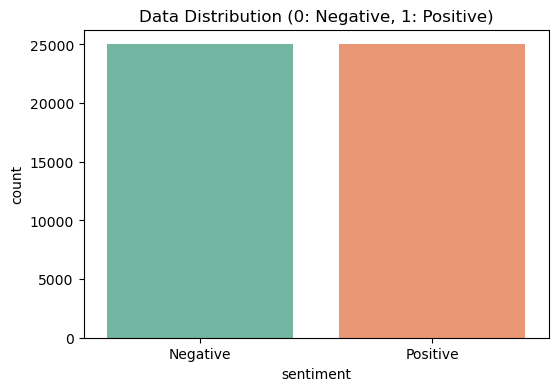

In [26]:
# 檢視資料標籤分布：確認類別是否平衡（或有嚴重不平衡）
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df, palette='Set2')
plt.title('Data Distribution (0: Negative, 1: Positive)')
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.show()

## 2. 資料前處理與標籤轉換
這一段會建立 `clean_text()` 函式，清理 HTML 標籤與多餘空白，並將 IMDB 的 `positive / negative` 轉成 `1 / 0`。

In [27]:
# 切分訓練/測試集：80% 訓練、20% 測試，使用 stratify 保持類別比例一致
X_train, X_test, y_train, y_test = train_test_split(
    df["review"], df["sentiment"], test_size=0.2, random_state=42, stratify=df["sentiment"]
)

# 取得英文停用詞並建立 TF-IDF 向量器：lowercase=True、移除停用詞、限制特徵數量至 5000 BoW
english_stopwords = stopwords.words("english")
vectorizer = TfidfVectorizer(lowercase=True, stop_words=english_stopwords, max_features=5000)

# 轉換文字為數值特徵（TF-IDF）
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## 3. 特徵抽取與模型訓練
這裡會將評論文字轉成 TF-IDF 特徵，接著訓練 Logistic Regression 分類器，作為後續所有預測的核心模型。

In [28]:
# 建立並訓練模型：使用 Logistic Regression 作為基礎的分類器
# max_iter 增大以確保收斂，random_state 固定結果可重現
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

# 在測試集上進行預測並計算評估指標：Accuracy 與分類報告（Precision/Recall/F1）
y_pred = model.predict(X_test_tfidf)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Negative", "Positive"], digits=4))

Accuracy: 0.8930

Classification Report:
               precision    recall  f1-score   support

    Negative     0.8989    0.8856    0.8922      5000
    Positive     0.8873    0.9004    0.8938      5000

    accuracy                         0.8930     10000
   macro avg     0.8931    0.8930    0.8930     10000
weighted avg     0.8931    0.8930    0.8930     10000



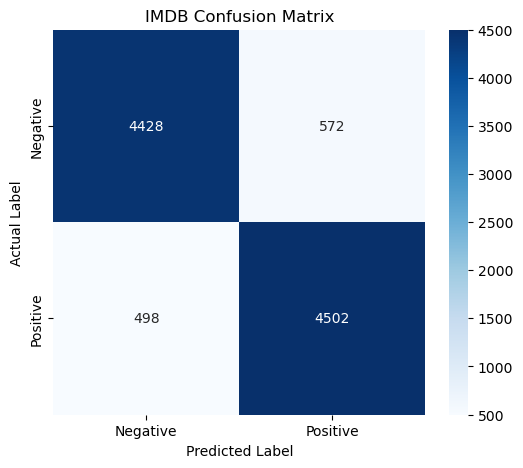

In [29]:
# 將混淆矩陣視覺化封裝成可重用函式，方便同時用於 IMDB 與 Amazon 資料
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix', class_labels=('Negative', 'Positive')):
    # 計算混淆矩陣
    cm = confusion_matrix(y_true, y_pred)

    # 使用 heatmap 顯示結果，讓分類錯誤一目了然
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(class_labels), yticklabels=list(class_labels))
    plt.title(title)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

# 先展示 IMDB 測試集的混淆矩陣
plot_confusion_matrix(y_test, y_pred, title='IMDB Confusion Matrix')

## 4. 混淆矩陣工具函式
這裡先把混淆矩陣畫圖包成共用函式，後面不論是 IMDB、Amazon，還是混合資料實驗都能直接重用。

In [30]:
# 即時文字輸入預測器：供期末報告 Demo 使用
# 函式名稱與簽章：predict_my_review(custom_review: str)
def predict_my_review(custom_review: str) -> None:
    """對單一輸入評論做清理、向量化與預測，並以友善格式印出結果。
    使用已訓練好的 `vectorizer` 與 `model`。"""
    # 1) 使用前面定義的 clean_text() 做文字前處理（不可改動）
    cleaned = clean_text(custom_review)

    # 2) 使用已經 fit 過的 vectorizer 進行 transform（絕對不要使用 fit_transform）
    X = vectorizer.transform([cleaned])

    # 3) 使用訓練好的 model 取得預測標籤與機率（信心指數）
    pred = model.predict(X)[0]
    proba = model.predict_proba(X)[0]
    # 信心度為模型對所選類別的機率（例如若 pred==1 就取 proba[1]）
    confidence = proba[int(pred)]

    # 4) 將結果格式化並印出，包含 Emoji 與百分比顯示到小數後兩位
    label_str = 'Positive (正評 👍)' if int(pred) == 1 else 'Negative (負評 👎)'
    conf_pct = confidence * 100

    print('─' * 60)
    print('輸入評論:')
    print(custom_review)
    print()
    print(f'預測結果: {label_str}')
    print(f'信心指數: {conf_pct:.2f}%')
    print('─' * 60)

# 範例測試（Demo 用）：極端正評、極端負評、帶有轉折的評論、簡短模糊評論
examples = [
    "This product is absolutely amazing! Exceeded all my expectations, highly recommend.",
    "Terrible quality. Broke after one use and customer service was useless. Never again.",
    "The item arrived on time and looks fine, but the battery life is awful so I wouldn't buy again.",
    "Not bad, but could be better."
]

# 所有範例
for ex in examples:
    predict_my_review(ex)


────────────────────────────────────────────────────────────
輸入評論:
This product is absolutely amazing! Exceeded all my expectations, highly recommend.

預測結果: Positive (正評 👍)
信心指數: 95.89%
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────
輸入評論:
Terrible quality. Broke after one use and customer service was useless. Never again.

預測結果: Negative (負評 👎)
信心指數: 94.69%
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────
輸入評論:
The item arrived on time and looks fine, but the battery life is awful so I wouldn't buy again.

預測結果: Negative (負評 👎)
信心指數: 84.02%
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────
輸入評論:
Not bad, but could be better.

預測結果: Negative (負評 👎)
信心指數: 99.82%
────────────────────────────────────────────────────────────


## 5. 即時評論 Demo
這一段提供 `predict_my_review()`，可以直接輸入一段評論文字，立即看到預測結果與信心指數，適合期末報告現場展示。

== Amazon 評論預測結果 ==
評估規則：overall 4.0-5.0 = Positive，1.0-2.0 = Negative，3.0 排除
Used rows for evaluation: 4773 / 4915
Accuracy vs overall: 0.7653

              precision    recall  f1-score   support

    Negative     0.1806    0.6944    0.2866       324
    Positive     0.9719    0.7705    0.8596      4449

    accuracy                         0.7653      4773
   macro avg     0.5763    0.7325    0.5731      4773
weighted avg     0.9182    0.7653    0.8207      4773

== 預測分佈 ==
Total: 4915
Positive (1): 3584 (72.92%)
Negative (0): 1331 (27.08%)


/var/folders/6f/y_f0vl9n7tlf6rqy7fhyz8nr0000gn/T/ipykernel_44187/4225625422.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="predicted_sentiment", data=df_amz, palette="Set2")


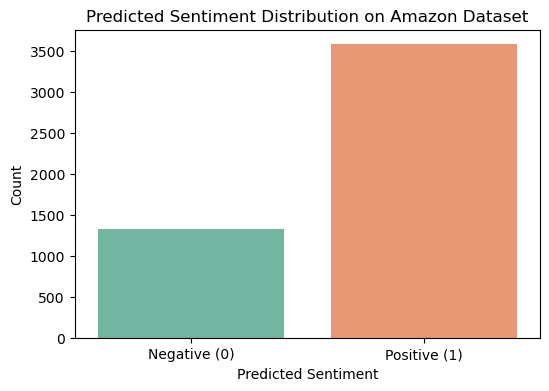

== 示例：被預測為 Positive 的評論（3 筆） ==


,reviewText,overall,predicted_sentiment
3409,"Great product, great price, great quality! I'...",5.0,1
3260,It was exactly the memory card I ordered. I te...,4.0,1
1283,We ordered two of these for our Samsung Galaxy...,5.0,1


== 示例：被預測為 Negative 的評論（3 筆） ==


,reviewText,overall,predicted_sentiment
3461,"So far, so good. No complaints, does what it i...",4.0,0
4098,I used this product with my Dell Venue 8 Pro. ...,2.0,0
4516,Has held data and transferred with my PC seaml...,5.0,0


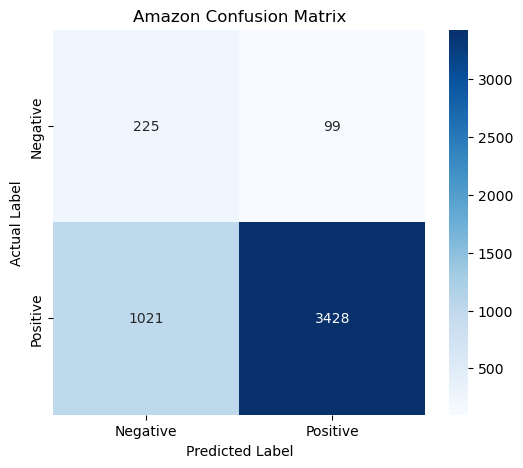

In [31]:
# 處理外部 Amazon 評論資料並做批次預測的單元格
# 這一格直接使用 reviewText 當作評論欄位，並使用 overall 來計算預測準確度

from pathlib import Path

fn = Path("amazon_reviews.csv")
if not fn.exists():
    raise FileNotFoundError(f"找不到檔案：{fn}. 請將 'amazon_reviews.csv' 放在 Notebook 同一資料夾。")

# 1) 讀取資料，不顯示 DataFrame info/head，直接進行後續預測
df_amz = pd.read_csv(fn)

# 2) 指定評論文字欄位為 reviewText，並補空字串避免 NaN 造成錯誤
if "reviewText" not in df_amz.columns:
    raise ValueError("資料中找不到 reviewText 欄位，請確認 Amazon 資料集欄位名稱。")

if "overall" not in df_amz.columns:
    raise ValueError("資料中找不到 overall 欄位，無法用來計算準確度。")

df_amz["reviewText"] = df_amz["reviewText"].fillna("")
df_amz["cleaned_review"] = df_amz["reviewText"].map(clean_text)

# 3) 使用已 fit 好的 vectorizer 進行 TF-IDF 轉換（只能使用 transform，不可重新 fit）
X_amz = vectorizer.transform(df_amz["cleaned_review"])

# 4) 使用訓練好的 model 進行預測，並加入新欄位 predicted_sentiment
df_amz["predicted_sentiment"] = model.predict(X_amz)

# 5) 使用 overall 建立更嚴格的實際標籤來計算準確度
#    4.0 到 5.0 視為正評，1.0 到 2.0 視為負評，3.0 先排除，不納入評估
df_amz["actual_sentiment"] = pd.NA
df_amz.loc[df_amz["overall"].between(4.0, 5.0, inclusive="both"), "actual_sentiment"] = 1
df_amz.loc[df_amz["overall"].between(1.0, 2.0, inclusive="both"), "actual_sentiment"] = 0
df_amz_eval = df_amz.dropna(subset=["actual_sentiment"]).copy()
df_amz_eval["actual_sentiment"] = df_amz_eval["actual_sentiment"].astype(int)

accuracy = accuracy_score(df_amz_eval["actual_sentiment"], df_amz_eval["predicted_sentiment"])
print("== Amazon 評論預測結果 ==")
print("評估規則：overall 4.0-5.0 = Positive，1.0-2.0 = Negative，3.0 排除")
print(f"Used rows for evaluation: {len(df_amz_eval)} / {len(df_amz)}")
print(f"Accuracy vs overall: {accuracy:.4f}")
print()
print(classification_report(
    df_amz_eval["actual_sentiment"],
    df_amz_eval["predicted_sentiment"],
    target_names=["Negative", "Positive"],
    digits=4,
))

# 6) 計算並印出預測分佈的筆數與百分比
#    這裡仍以全部 Amazon 資料的模型預測結果作分佈展示
total = len(df_amz)
counts = df_amz["predicted_sentiment"].value_counts().sort_index()
neg = int(counts.get(0, 0))
pos = int(counts.get(1, 0))

print("== 預測分佈 ==")
print(f"Total: {total}")
print(f"Positive (1): {pos} ({(pos / total * 100) if total else 0:.2f}%)")
print(f"Negative (0): {neg} ({(neg / total * 100) if total else 0:.2f}%)")

# 7) 畫出長條圖展示預測分佈
plt.figure(figsize=(6, 4))
sns.countplot(x="predicted_sentiment", data=df_amz, palette="Set2")
plt.xticks([0, 1], ["Negative (0)", "Positive (1)"])
plt.title("Predicted Sentiment Distribution on Amazon Dataset")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Count")
plt.show()

# 8) 隨機抽樣展示：3 筆預測為正評與 3 筆預測為負評，用於人工檢視結果合理性
print("== 示例：被預測為 Positive 的評論（3 筆） ==")
positives = df_amz[df_amz["predicted_sentiment"] == 1][["reviewText", "overall", "predicted_sentiment"]].dropna()
if len(positives) >= 3:
    display(positives.sample(3, random_state=42))
else:
    display(positives)

print("== 示例：被預測為 Negative 的評論（3 筆） ==")
negatives = df_amz[df_amz["predicted_sentiment"] == 0][["reviewText", "overall", "predicted_sentiment"]].dropna()
if len(negatives) >= 3:
    display(negatives.sample(3, random_state=42))
else:
    display(negatives)

# 9) 顯示 Amazon 預測結果的混淆矩陣，觀察模型在外部資料上的錯分情況
plot_confusion_matrix(
    df_amz_eval["actual_sentiment"],
    df_amz_eval["predicted_sentiment"],
    title='Amazon Confusion Matrix',
    class_labels=('Negative', 'Positive')
)

# 選擇性的：將帶有預測結果的 DataFrame 存為新檔案，方便後續分析或報告（取消下列註解可啟用）
# out_fn = Path('amazon_reviews_with_predictions.csv')
# df_amz.to_csv(out_fn, index=False, encoding='utf-8')
# print(f'已匯出包含預測結果的檔案：{out_fn}')

## 6. Amazon 跨領域批次預測
這一段會讀取 `amazon_reviews.csv`，使用 `reviewText` 做批次預測，並用更嚴格的 `overall` 規則來評估模型表現。

== 混合資料集切分結果 ==
Train size: 27386 (IMDB: 25000, Amazon: 2386)
Test size : 27387 (IMDB: 25000, Amazon: 2387)

== 混合資料模型結果 ==
Accuracy: 0.8872

              precision    recall  f1-score   support

    Negative     0.8935    0.8585    0.8756     12662
    Positive     0.8823    0.9120    0.8969     14725

    accuracy                         0.8872     27387
   macro avg     0.8879    0.8852    0.8863     27387
weighted avg     0.8874    0.8872    0.8871     27387



/var/folders/6f/y_f0vl9n7tlf6rqy7fhyz8nr0000gn/T/ipykernel_44187/3221537736.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pred_dist.index.astype(str), y=pred_dist.values, palette="Set2")


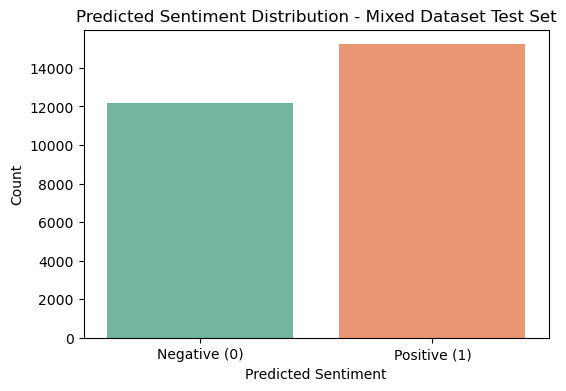

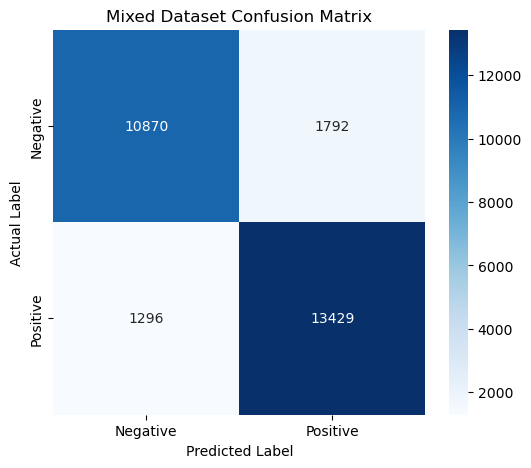

== 混合資料測試集預測示例（前 5 筆） ==


,review,sentiment,predicted_sentiment
0,If you are a six-year-old boy who's into dinos...,0,0
1,"When I voted my ""1"" for this film I noticed th...",0,0
2,"While there aren't any talking animals, big la...",1,1
3,"Did you ever think, like after watching a horr...",0,0
4,"I was expecting to love this movie--film noir,...",0,0


In [32]:
# 混合資料實驗：用一半 IMDB + 一半 Amazon 訓練，另一半 + 另一半 測試
# 這一格把前面的功能整理成完整流程：資料準備、建模、預測評估、柱狀圖與混淆矩陣

from pathlib import Path

# ---------- 1) 資料讀取與前處理 ----------
# IMDB 資料：使用 review / sentiment
imdb_path = Path("IMDB_Dataset.csv")
if not imdb_path.exists():
    raise FileNotFoundError(f"找不到檔案：{imdb_path}")

imdb_df = pd.read_csv(imdb_path)
imdb_df["review"] = imdb_df["review"].fillna("").map(clean_text)
imdb_df["sentiment"] = imdb_df["sentiment"].astype(str).str.lower().str.strip().map({"positive": 1, "negative": 0})

# Amazon 資料：使用 reviewText / overall，並套用更嚴格的標籤規則
amazon_path = Path("amazon_reviews.csv")
if not amazon_path.exists():
    raise FileNotFoundError(f"找不到檔案：{amazon_path}")

amazon_df = pd.read_csv(amazon_path)
if "reviewText" not in amazon_df.columns:
    raise ValueError("Amazon 資料中找不到 reviewText 欄位。")
if "overall" not in amazon_df.columns:
    raise ValueError("Amazon 資料中找不到 overall 欄位。")

amazon_df["reviewText"] = amazon_df["reviewText"].fillna("")
amazon_df["review"] = amazon_df["reviewText"].map(clean_text)
amazon_df["sentiment"] = pd.NA
amazon_df.loc[amazon_df["overall"].between(4.0, 5.0, inclusive="both"), "sentiment"] = 1
amazon_df.loc[amazon_df["overall"].between(1.0, 2.0, inclusive="both"), "sentiment"] = 0
amazon_df = amazon_df.dropna(subset=["sentiment"]).copy()
amazon_df["sentiment"] = amazon_df["sentiment"].astype(int)

# ---------- 2) 各自切成一半訓練、一半測試 ----------
# 這裡是「IMDB 一半 + Amazon 一半」做訓練，另一半 + 另一半 做測試
imdb_train, imdb_test = train_test_split(
    imdb_df,
    test_size=0.5,
    random_state=42,
    stratify=imdb_df["sentiment"],
)
amazon_train, amazon_test = train_test_split(
    amazon_df,
    test_size=0.5,
    random_state=42,
    stratify=amazon_df["sentiment"],
)

train_df = pd.concat([imdb_train[["review", "sentiment"]], amazon_train[["review", "sentiment"]]], ignore_index=True)
test_df = pd.concat([imdb_test[["review", "sentiment"]], amazon_test[["review", "sentiment"]]], ignore_index=True)

print("== 混合資料集切分結果 ==")
print(f"Train size: {len(train_df)} (IMDB: {len(imdb_train)}, Amazon: {len(amazon_train)})")
print(f"Test size : {len(test_df)} (IMDB: {len(imdb_test)}, Amazon: {len(amazon_test)})")
print()

# ---------- 3) 特徵向量化與模型訓練 ----------
# 只使用 train_df 來 fit，避免資料洩漏
mixed_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=english_stopwords,
    max_features=5000,
)

X_train_mixed = mixed_vectorizer.fit_transform(train_df["review"])
X_test_mixed = mixed_vectorizer.transform(test_df["review"])
y_train_mixed = train_df["sentiment"]
y_test_mixed = test_df["sentiment"]

mixed_model = LogisticRegression(max_iter=1000, random_state=42)
mixed_model.fit(X_train_mixed, y_train_mixed)
y_pred_mixed = mixed_model.predict(X_test_mixed)

# ---------- 4) 評估指標 ----------
accuracy_mixed = accuracy_score(y_test_mixed, y_pred_mixed)
print("== 混合資料模型結果 ==")
print(f"Accuracy: {accuracy_mixed:.4f}")
print()
print(classification_report(
    y_test_mixed,
    y_pred_mixed,
    target_names=["Negative", "Positive"],
    digits=4,
))

# ---------- 5) 預測結果分佈柱狀圖 ----------
# 這裡顯示模型在測試集上的預測分佈
pred_dist = pd.Series(y_pred_mixed).value_counts().sort_index()
plt.figure(figsize=(6, 4))
sns.barplot(x=pred_dist.index.astype(str), y=pred_dist.values, palette="Set2")
plt.xticks([0, 1], ["Negative (0)", "Positive (1)"])
plt.title("Predicted Sentiment Distribution - Mixed Dataset Test Set")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Count")
plt.show()

# ---------- 6) 混淆矩陣 ----------
plot_confusion_matrix(
    y_test_mixed,
    y_pred_mixed,
    title="Mixed Dataset Confusion Matrix",
    class_labels=("Negative", "Positive"),
)

# ---------- 7) 可選：顯示幾筆預測結果，方便報告展示 ----------
result_preview = test_df[["review", "sentiment"]].copy()
result_preview["predicted_sentiment"] = y_pred_mixed
print("== 混合資料測試集預測示例（前 5 筆） ==")
display(result_preview.head())

## 7. 混合資料實驗
最後這段會把 IMDB 與 Amazon 各切一半，前半拿來訓練、後半拿來測試，完整展示模型在混合語料上的效果。